# Model Fitness -  Estrategia de interacción con clientes basada en datos analíticos
___



**Descripción del proyecto**

Uno de los problemas más comunes que enfrentan los gimnasios, emtre ellos *Model Fitness*, y otros servicios es la pérdida de clientes. ¿Cómo descubres si un/a cliente ya no está contigo? Puedes calcular la pérdida en función de las personas que se deshacen de sus cuentas o no renuevan sus contratos. Sin embargo, a veces no es obvio que un/a cliente se haya ido: puede que se vaya de puntillas.

En el caso de un gimnasio, tiene sentido decir que un/a cliente se ha ido si no viene durante un mes. Por supuesto, es posible que estén en Cancún y retomen sus visitas cuando regresen, pero ese no es un caso típico. Por lo general, si un/a cliente se une, viene varias veces y luego desaparece, es poco probable que regrese.

Con el fin de combatir la cancelación, Model Fitness ha digitalizado varios de sus perfiles de clientes. 

**Objetivo**

El objetivo de este proyecto es analizar los perfiles y elaborar una estrategia de retención de clientes.



Los que se plantea hacer en este proyecto es:

- Aprender a predecir la probabilidad de pérdida (para el próximo mes) para cada cliente.
- Elaborar retratos de usuarios típicos: selecciona los grupos más destacados y describe sus características principales.
- Analizar los factores que más impactan la pérdida.
- Sacar conclusiones básicas y elaborar recomendaciones para mejorar la atención al cliente:
  
      a) identificar a los grupos objetivo;
      b) sugerir medidas para reducir la rotación;
      c) describir cualquier otro patrón que observes con respecto a la interacción con los clientes.

## Paso 1. Descargar los datos

In [1]:
#Se cargan las librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score

In [2]:
#Se cargan los datos para hacer el analisis 
gym = pd.read_csv('/datasets/gym_churn_us.csv')

## Paso 2. Llevar a cabo el análisis exploratorio de datos (EDA)

### 2.1. Se observa la información contenido en el archivo proporcionado

In [3]:
#Se revisa la información contenida en el dataset para haer los analisis
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [4]:
gym.shape

(4000, 14)

In [5]:
gym.columns

Index(['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone',
       'Contract_period', 'Group_visits', 'Age',
       'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime',
       'Avg_class_frequency_total', 'Avg_class_frequency_current_month',
       'Churn'],
      dtype='object')

In [6]:
gym.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [7]:
gym.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

Despúes de revisar la información proporcionada en el dataset vemos que todo lo que necesitamos se ve presente y listo para proseguir con el análisis exporatorio.

### 2.2. Observar valores medios

In [8]:
# Se realiza filtro por fecha de cancelación para proseguir con el análisis
gym.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


### 2.3. Trazar Histogramas

In [9]:
#Se desarrolla una función para facilitar la realización de histogramas y poder visualizar la información porporcinada
def hist_graph(x, group_col, key_cols):
    '''
    Función para hcaer histogramas y 
    distribuciones de caracteriastas de las personas
    que cancelaron y no.
    '''
    x_new = x.copy()
    x_new[key_cols] = gym[key_cols] # Nos aseguramos que el dataframe este correctamente definido

    #Se Definen paletas para los clusters
    unique_clusters = x[group_col].unique()
    colors = sns.color_palette('rocket', len(unique_clusters)) #Se agrega paleta de colores distintos
    color_dict = dict(zip(unique_clusters, colors))            #Asocia cada cluster a un color

    for i in key_cols:
        plt.figure(figsize=(10,6)) #Se crea una nueva grafica pora cada columna
        for cl in x[group_col].unique():
            sns.histplot(
                data = x_new[x_new[group_col]==cl][i],
                label ='{} = {}'.format(group_col, str(cl)), 
                bins  = 10,
                color = color_dict[cl],
                alpha = 0.5,
                kde   = True)
        plt.title(i)
        plt.legend()
        plt.show()


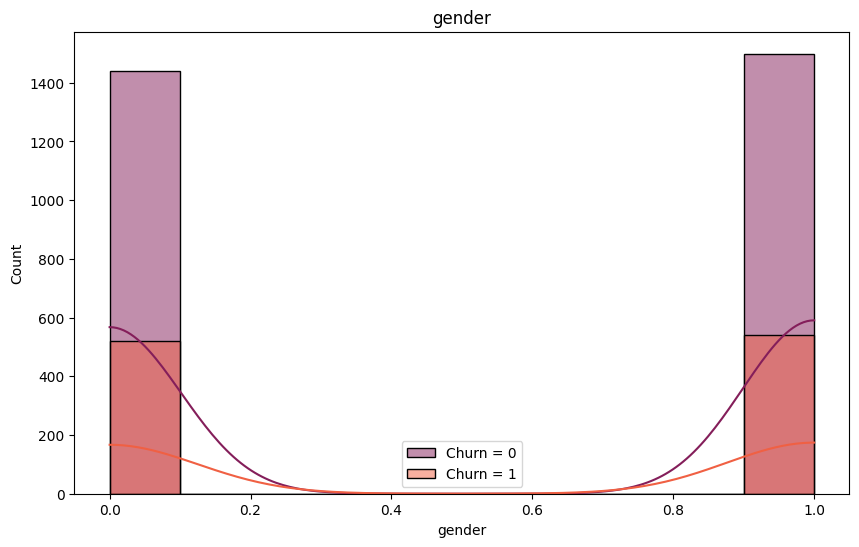

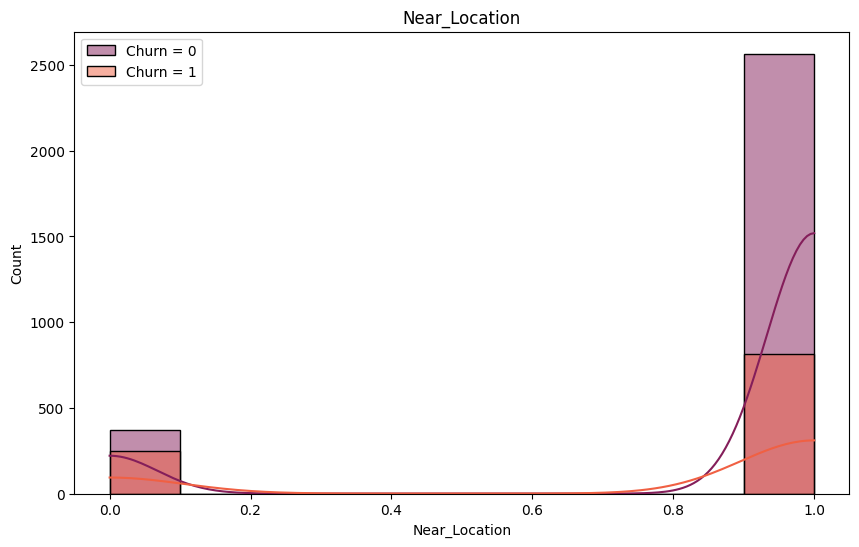

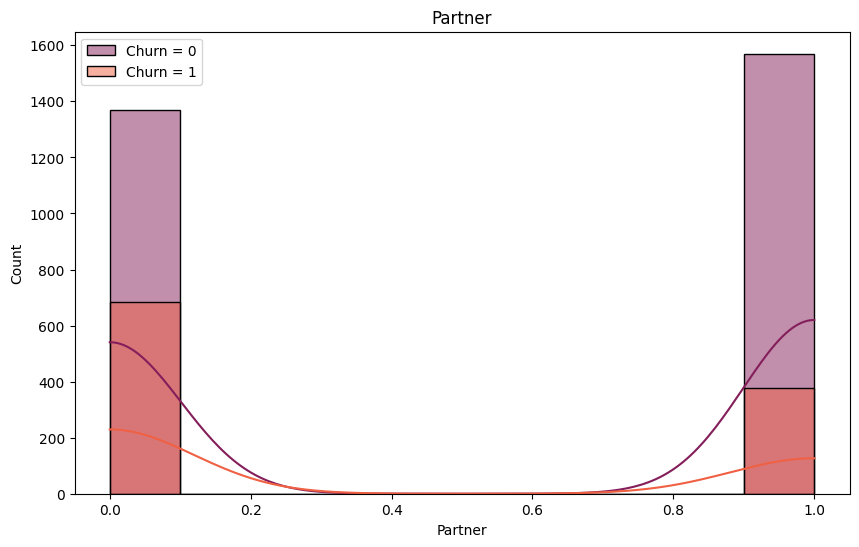

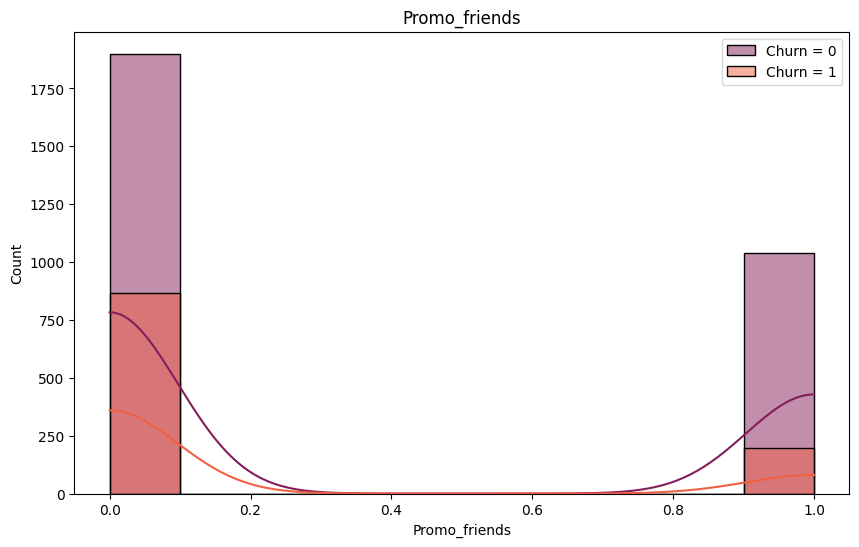

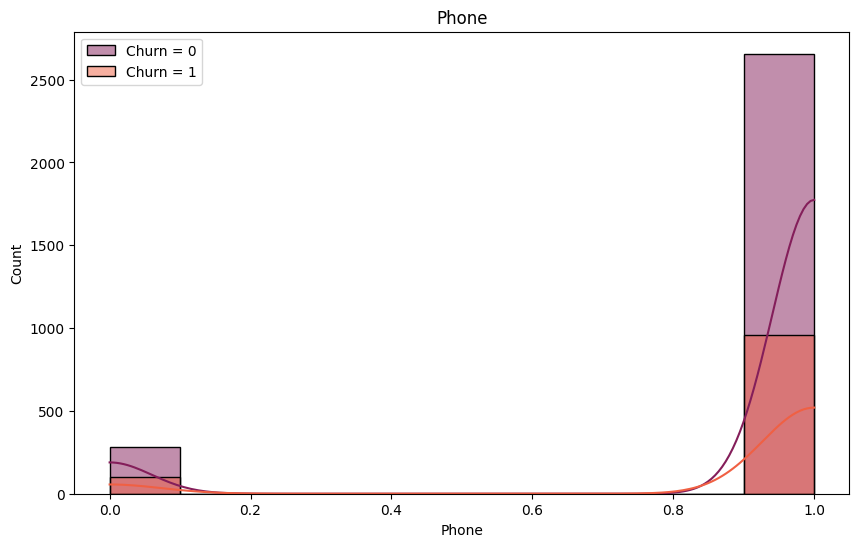

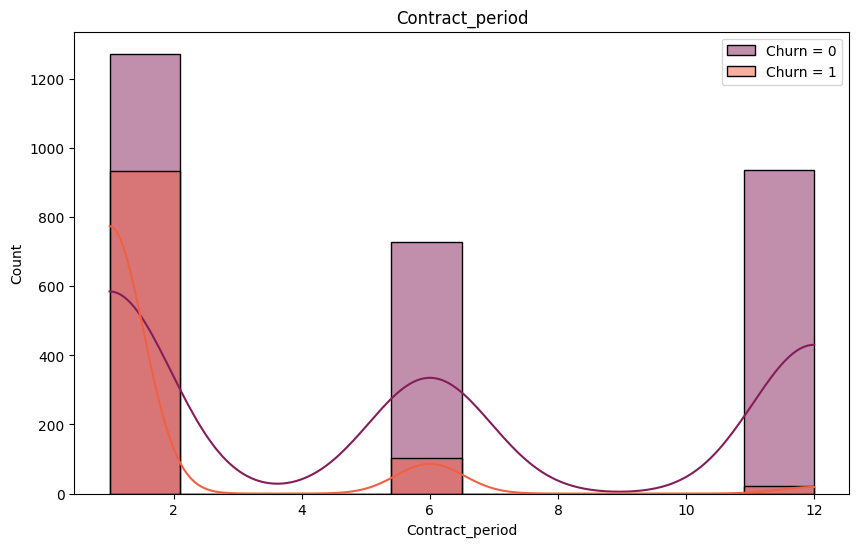

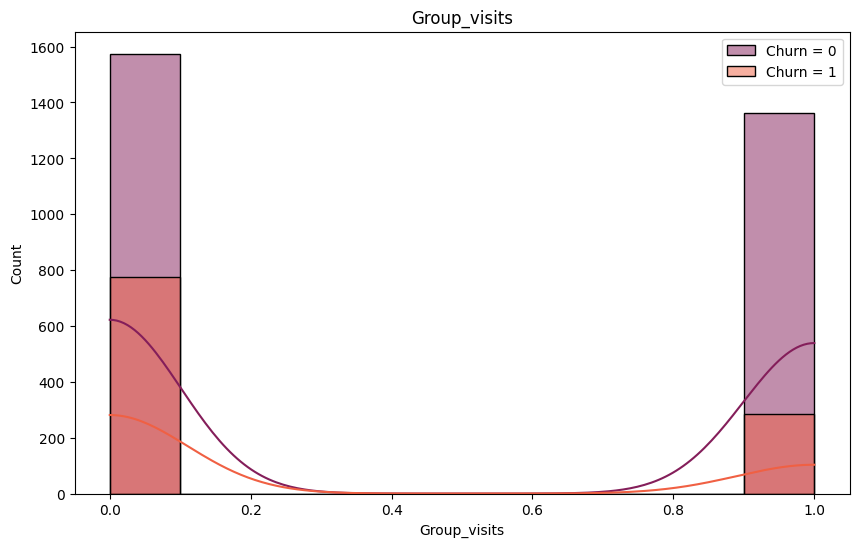

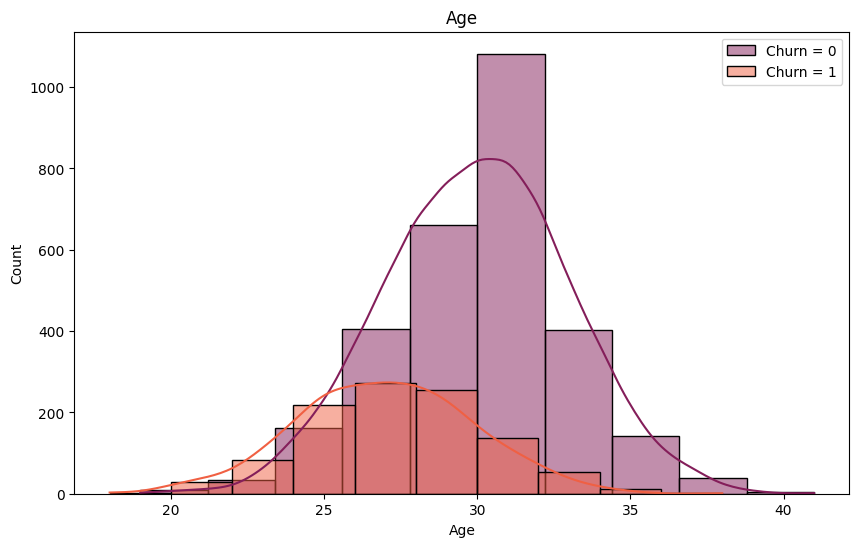

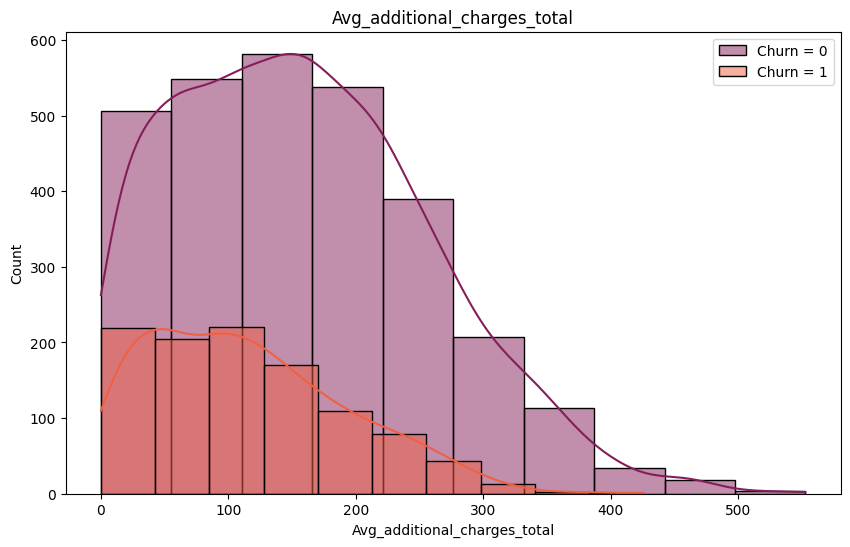

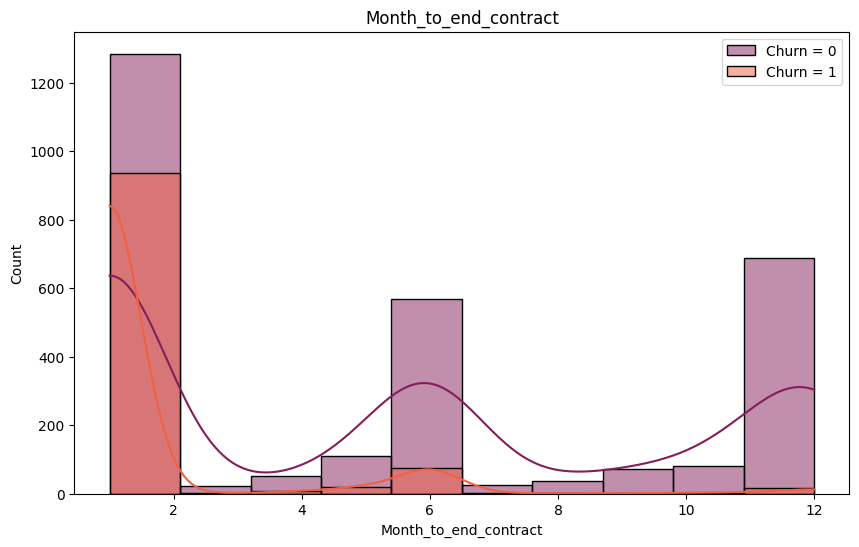

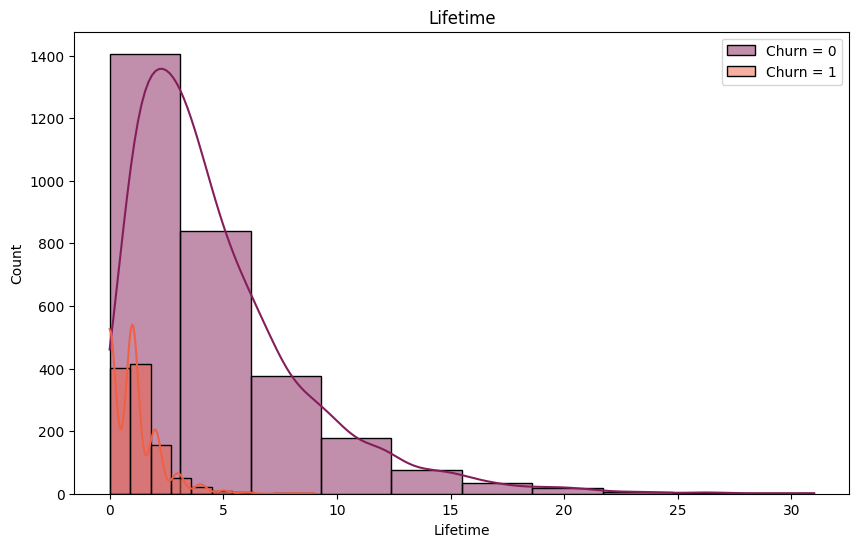

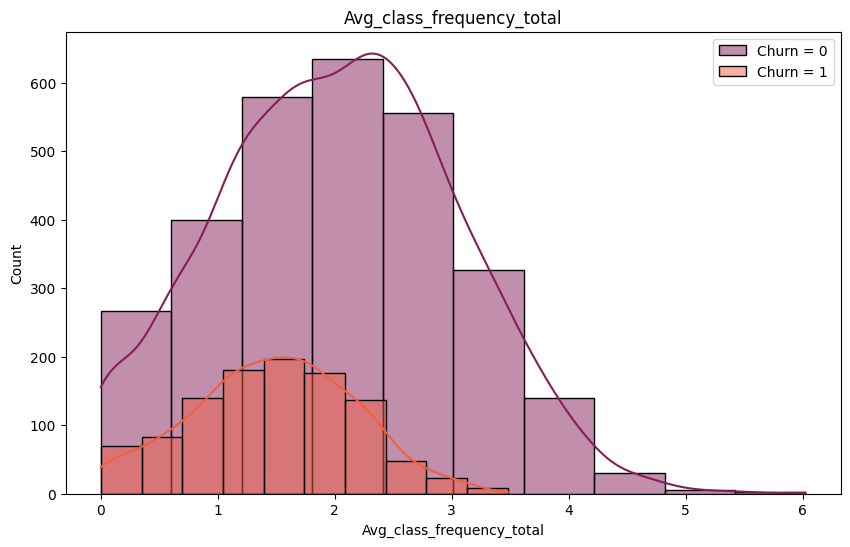

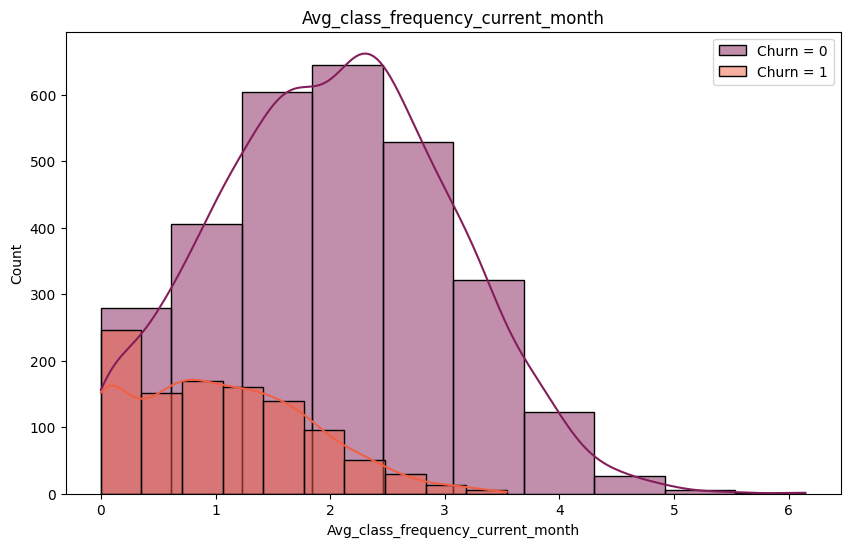

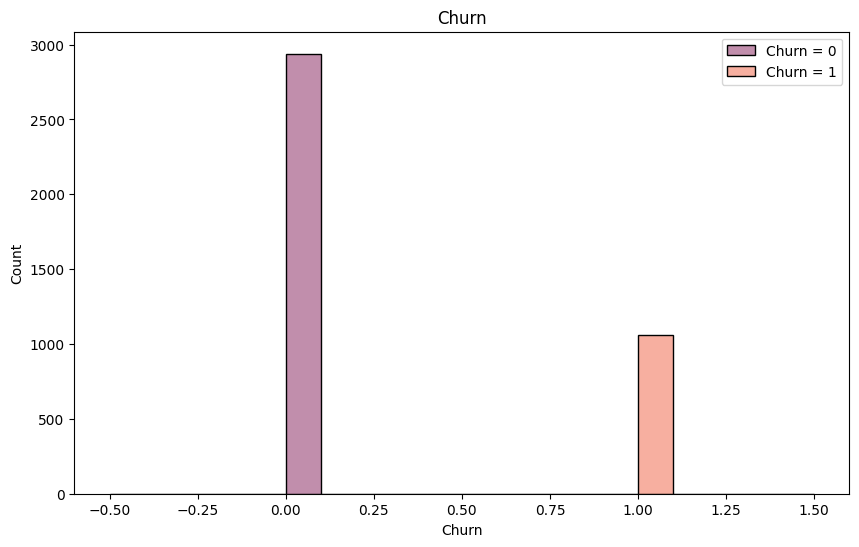

In [10]:
hist_graph(gym,'Churn', gym.columns)

### 2.3. Matriz de correlación

In [11]:
#Se crea matriz de correlación
matrix = gym.corr()
matrix

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
Near_Location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
Partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
Promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
Phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
Contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
Group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
Age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
Avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
Month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


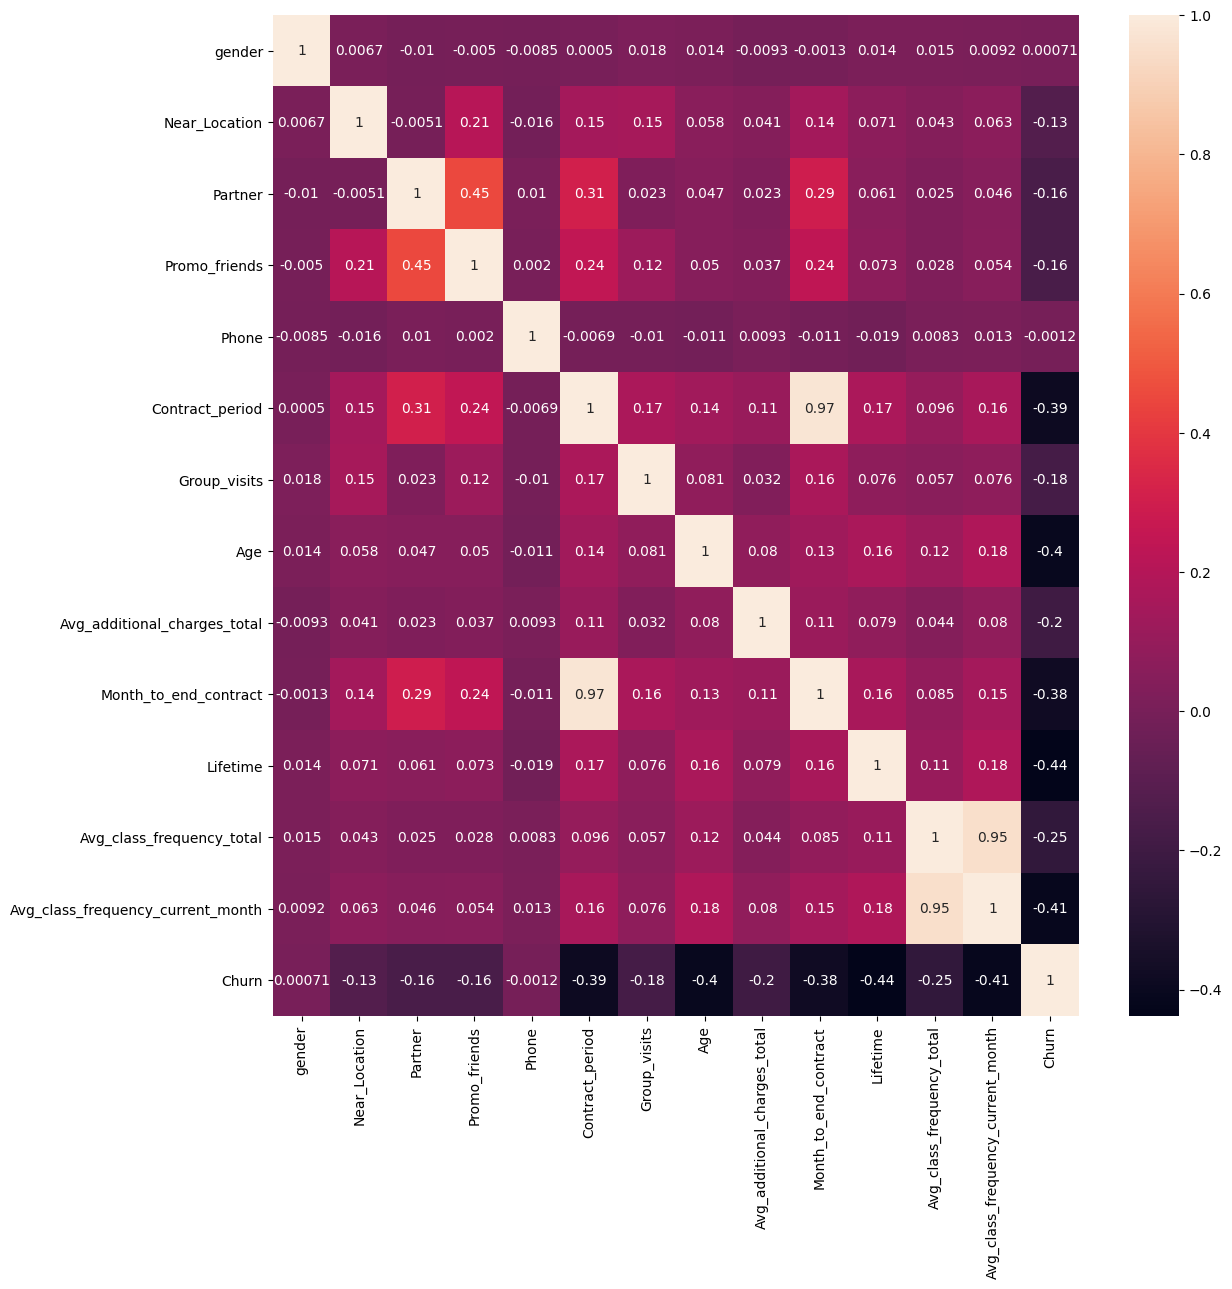

In [12]:
plt.figure(figsize = (13,13))
sns.heatmap(matrix, annot=True)
plt.show()

## Paso 3. Construir un modelo para predecir la cancelación de usuarios

Crea un modelo de clasificación binaria para clientes donde la característica objetivo es la marcha del usuario o la usuaria el mes siguiente.

### 3.1 Divide los datos en conjuntos de entrenamiento y validación utilizando la función train_test_split().

In [13]:
#Se hace la división de los datos para hacer el entremaniento de los datos
features = gym.drop('Churn', axis = 1)
target = gym['Churn']

#Se dividen los datos entre los entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(features, target, test_size = 0.2, random_state = 0)

#Se revisa el tamaño de la división de la información
print('Datos entrenamiento:', X_train.shape)
print('Datos validación:', X_val.shape)
print('Objetivo entrenamiento:', y_train.shape)
print('Objetivo validación:', y_val.shape)

Datos entrenamiento: (3200, 13)
Datos validación: (800, 13)
Objetivo entrenamiento: (3200,)
Objetivo validación: (800,)


### 3.2 Entrena el modelo en el set de entrenamiento con dos métodos:

#### - Regresión logística

In [14]:
#Se define el algoritmo y entrena para el modelo de regresión logística
lr_model =  LogisticRegression(random_state = 0)
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [15]:
#Se realizan las predicciones
y_prob_lr = lr_model.predict_proba(X_val)
y_pred_lr = lr_model.predict(X_val)

#### - Bosque aleatorio

In [16]:
#Se define el algoritmo y entrena para el modelo de random forest
rf_model = RandomForestClassifier(random_state = 0, n_estimators = 100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [17]:
#Se realizan las predicciones
rf_prob = rf_model.predict_proba(X_val)[:,1]
rf_pred = rf_model.predict(X_val)

### 3.3 Evalúa la exactitud, precisión y recall para ambos modelos utilizando los datos de validación:

#### - Regresión logística

In [18]:
#Se muestran las métricas para evaluar la exactitud del modelo de regresión logística
print('La Exactitud del modelo de Regresión es: {:.2f}'.format(accuracy_score(y_val, y_pred_lr)))
print('La Presición del modelo de Regresión es: {:.2f}'.format(precision_score(y_val, y_pred_lr)))
print('La Sensibilidad del modelo de Regresión es: {:.2f}'.format(recall_score(y_val, y_pred_lr)))

La Exactitud del modelo de Regresión es: 0.91
La Presición del modelo de Regresión es: 0.82
La Sensibilidad del modelo de Regresión es: 0.80


#### - Bosque aleatorio

In [19]:
#Se muestran las métricas para evaluar la exactitud del modelo de random forest
print('La Exactitud del modelo de Random Forest es: {:.2f}'.format(accuracy_score(y_val, rf_pred)))
print('La Presición del modelo de Random Forest es: {:.2f}'.format(precision_score(y_val, rf_pred)))
print('La Sensibilidad del modelo de Random Forest es: {:.2f}'.format(recall_score(y_val, rf_pred)))


La Exactitud del modelo de Random Forest es: 0.92
La Presición del modelo de Random Forest es: 0.84
La Sensibilidad del modelo de Random Forest es: 0.82


Despúes de ejecutar y evaluar ambos modemos, podemos observar que el de Bosque Aleatorio o *Random Forest* es el modelo ganador en todas las metricas. 

Por este razón que es el modelo que recomendariamos usar para el análisis de Model Fitness es el de Bosque Aleatorio o *Random Forest* por los resultados demostrados:

 - Exactitud general del 92%
 - Presición en la predicción de clientes que cancelan (*Churn*) del 84%
 - Detecta mejor los clientes que se van con el 82% 

## Paso 4. Crear clústeres de usuarios/as

Deja de lado la columna con datos sobre la cancelación e identifica los clústeres de objetos (usuarios/as):

### 4.1 Estandariza los datos

In [20]:
#Se define el algoritmo y entrena para la estandarización de datos
sc =  StandardScaler()
x_sc = sc.fit_transform(gym.drop('Churn', axis = 1))

### 4.2.1 Utiliza la función linkage() para crear una matriz de distancias basada en la matriz de características estandarizada

In [21]:
#Se utiliza la funcion linkage para crear la matriz
linked = linkage(x_sc, method = 'ward')

### 4.2.2 Trazar un dendrograma

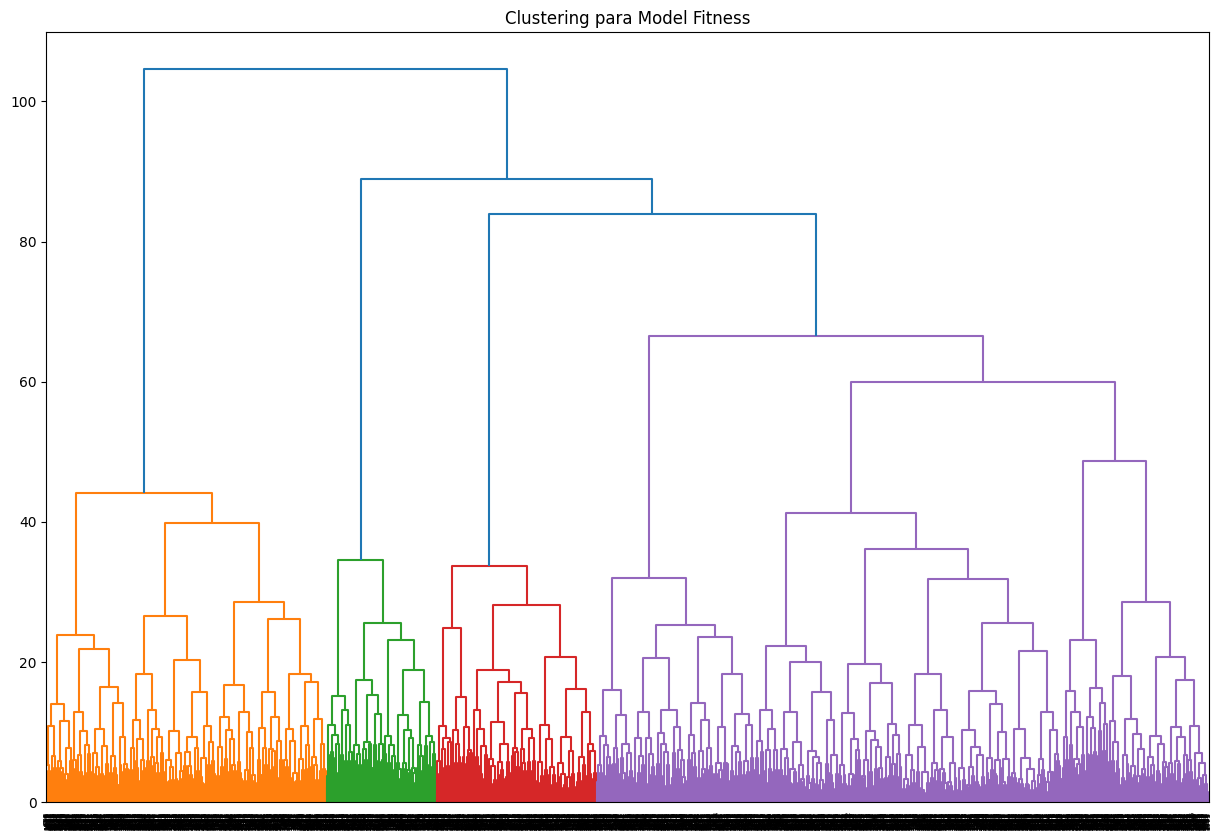

In [22]:
#Se traza el dendograma para visualziar los clusters de clientes
plt.figure(figsize = (15,10))
dendrogram(linked, orientation = 'top')
plt.title('Clustering para Model Fitness')
plt.show()

### 4.3 Entrena el modelo de clustering con el algortimo K-means y predice los clústeres de clientes

In [23]:
#Se define el algoritmo y entrena el modelo para clusterizar clientes
km = KMeans(n_clusters = 5, random_state = 42, init='k-means++', n_init=10)
labels = km.fit_predict(gym.drop('Churn', axis = 1))

In [24]:
#Se integra la columna 'cluster_km' al datafrema inicial
gym['cluster_km'] = labels

### 4.4 Mira los valores medios de característica para los clústeres

In [25]:
#Se agrupa la informacion por cluester para vizualizar los valores medios de las características de los clusters
gym.groupby('cluster_km').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.517275,0.844028,0.459033,0.281343,0.901283,4.315893,0.417572,28.972359,102.702388,3.990128,3.524186,1.848436,1.705247,0.324778
1,0.527665,0.875843,0.508772,0.346829,0.900135,5.368421,0.426451,29.314440,246.249623,4.967611,4.143050,1.923810,1.862351,0.179487
2,0.507292,0.842708,0.490625,0.310417,0.896875,4.740625,0.422917,29.401042,170.592035,4.379167,3.758333,1.875226,1.762253,0.237500
3,0.465986,0.853741,0.513605,0.336735,0.928571,5.772109,0.435374,29.877551,352.178412,5.329932,4.401361,1.991659,1.978845,0.054422
4,0.506048,0.823589,0.486895,0.297379,0.907258,4.160282,0.379032,28.888105,34.231466,3.827621,3.384073,1.847083,1.700854,0.357863


### 4.5 Traza distribuciones de características para los clústeres

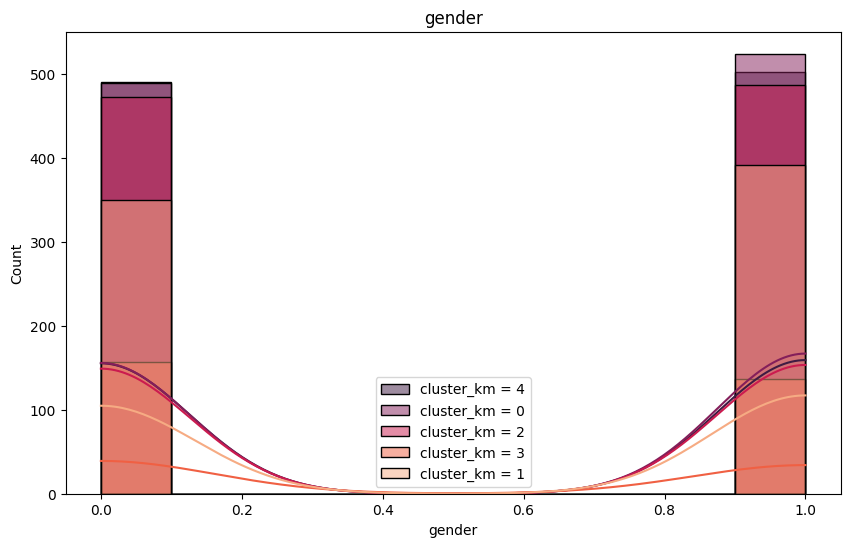

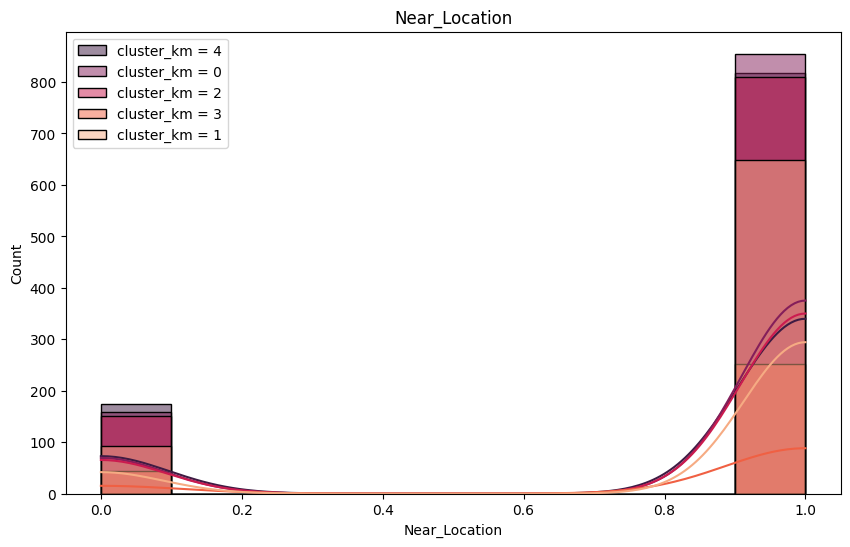

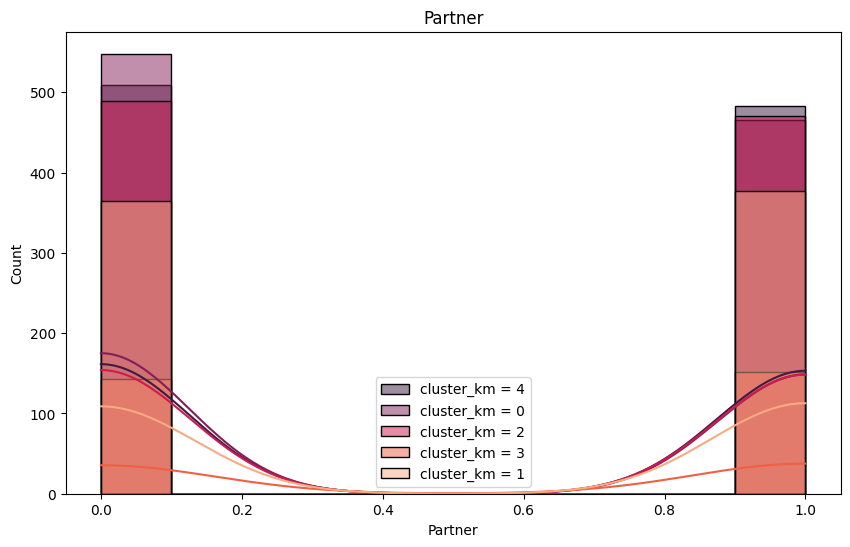

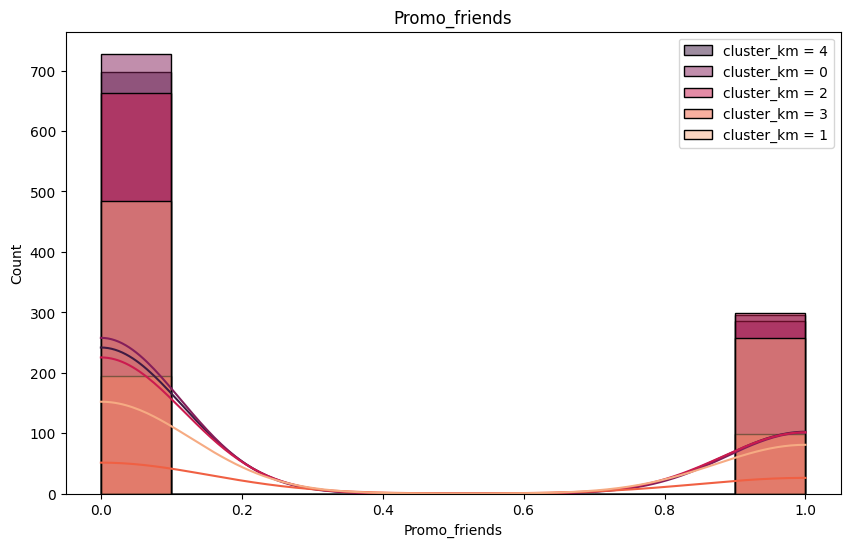

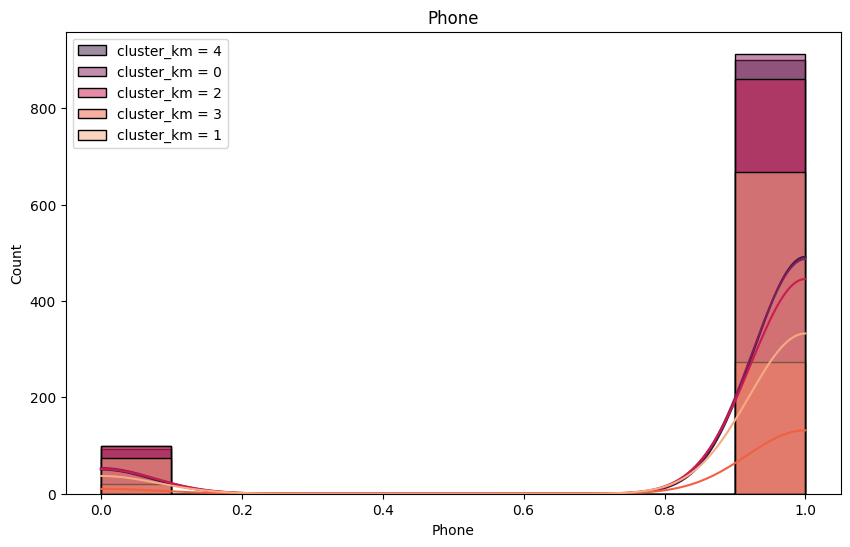

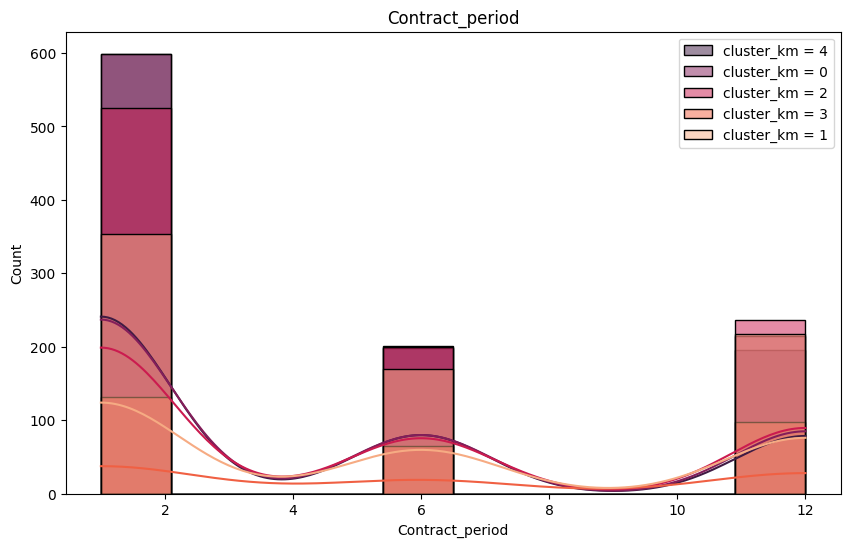

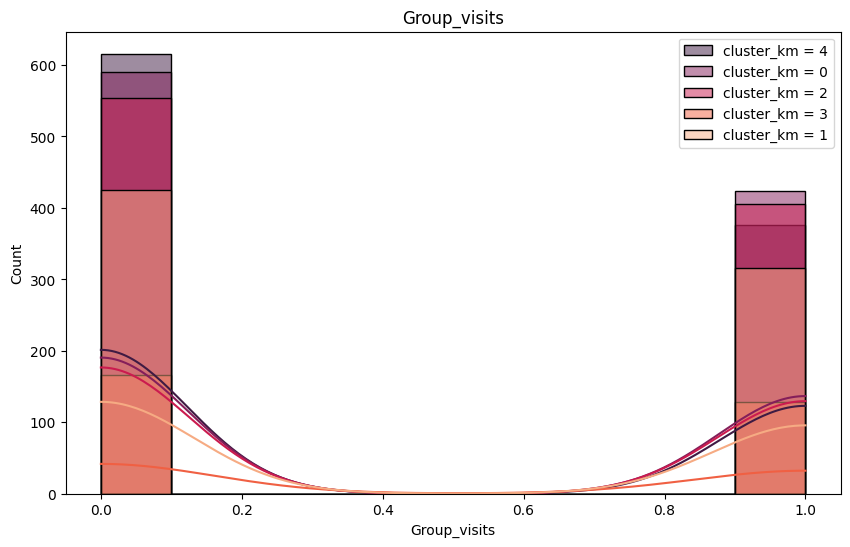

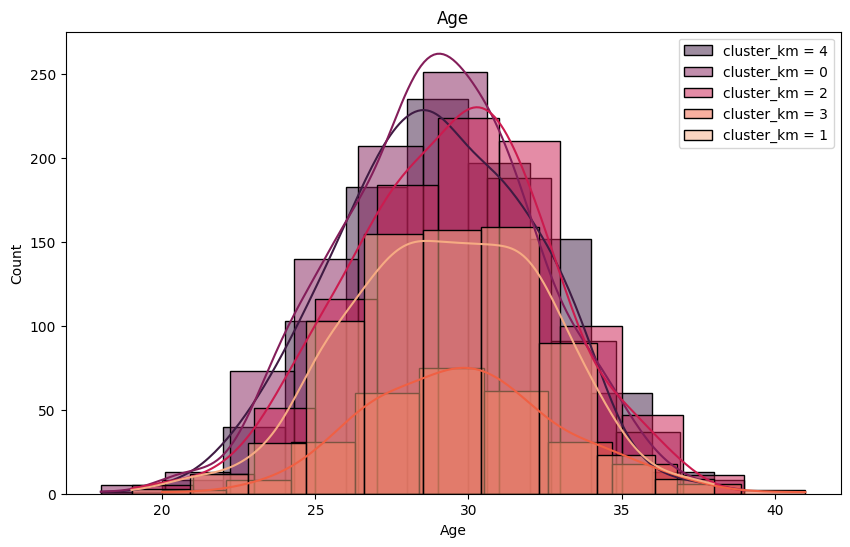

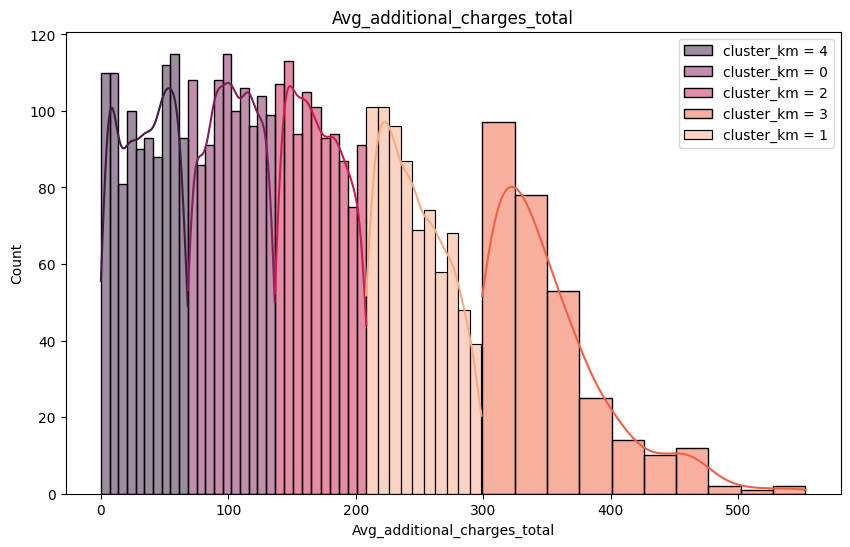

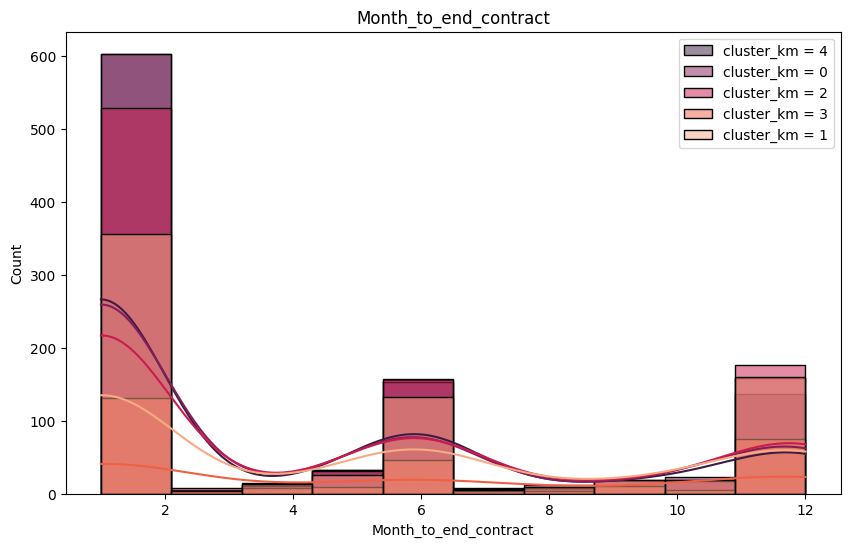

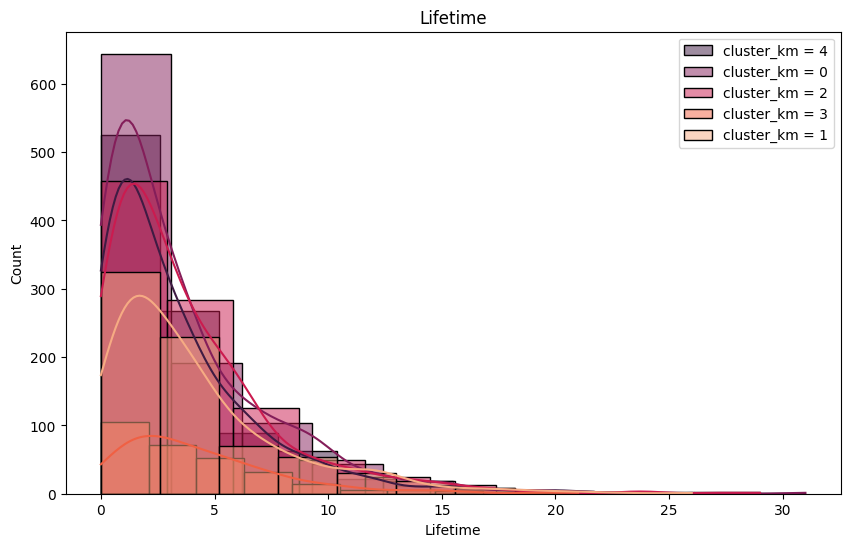

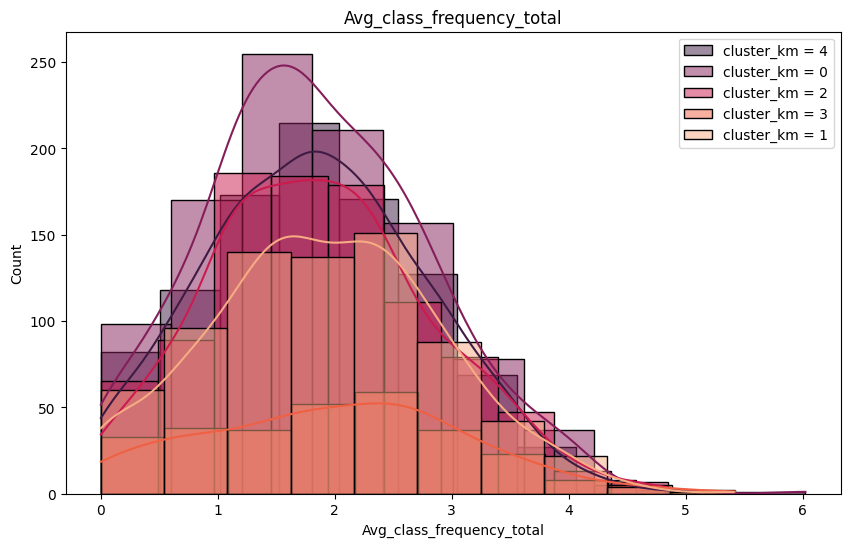

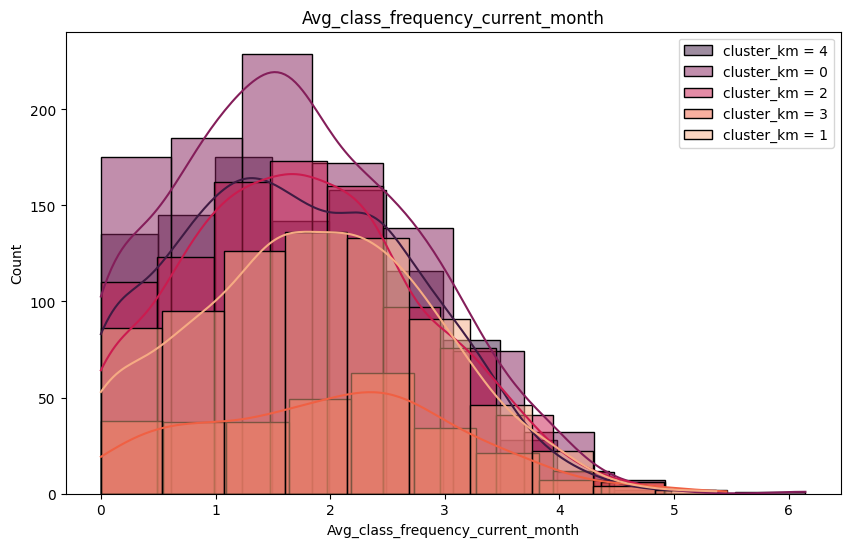

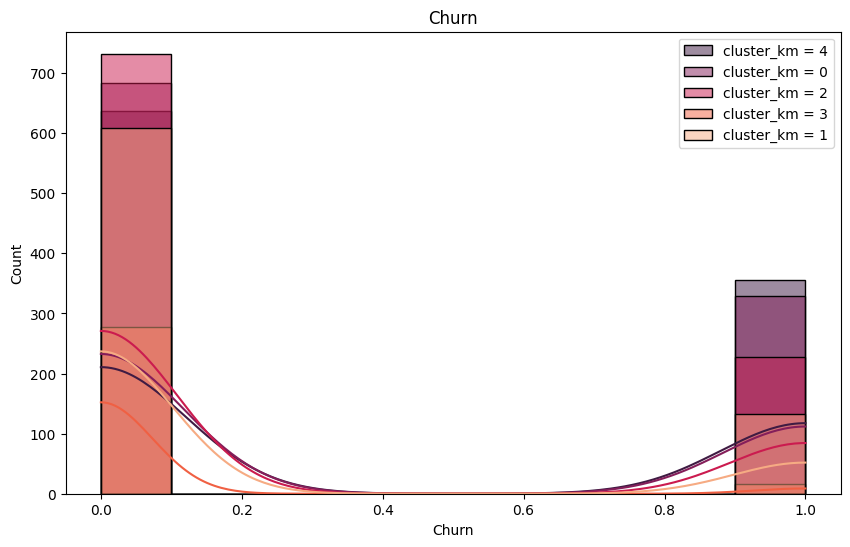

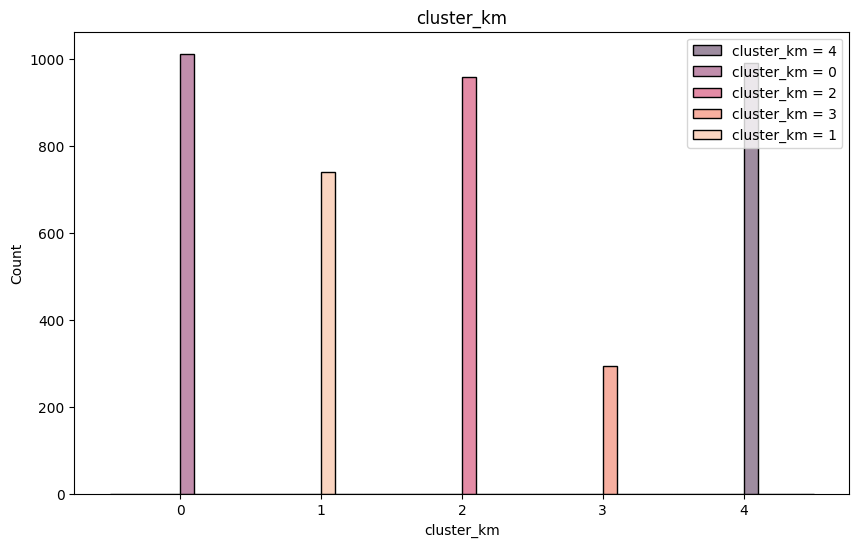

In [26]:
#Se hace uso de la función desarrollada (paso 2.3) para la visialización de histogramas 
hist_graph(gym,'cluster_km', gym.columns)

### 4.6 Calcula la tasa de cancelación para cada clúster

In [27]:
#Se hace el calculo de la tasa de cancelación para cada cluster
gym.groupby('cluster_km')['Churn'].mean()

cluster_km
0    0.324778
1    0.179487
2    0.237500
3    0.054422
4    0.357863
Name: Churn, dtype: float64

In [28]:
gym.groupby('cluster_km').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster_km,,,,,,,,,,,,,,
0,0.517275,0.844028,0.459033,0.281343,0.901283,4.315893,0.417572,28.972359,102.702388,3.990128,3.524186,1.848436,1.705247,0.324778
1,0.527665,0.875843,0.508772,0.346829,0.900135,5.368421,0.426451,29.314440,246.249623,4.967611,4.143050,1.923810,1.862351,0.179487
2,0.507292,0.842708,0.490625,0.310417,0.896875,4.740625,0.422917,29.401042,170.592035,4.379167,3.758333,1.875226,1.762253,0.237500
3,0.465986,0.853741,0.513605,0.336735,0.928571,5.772109,0.435374,29.877551,352.178412,5.329932,4.401361,1.991659,1.978845,0.054422
4,0.506048,0.823589,0.486895,0.297379,0.907258,4.160282,0.379032,28.888105,34.231466,3.827621,3.384073,1.847083,1.700854,0.357863


## Paso 5. Saca conclusiones y haz recomendaciones básicas sobre el trabajo con clientes

Después de analizar la información proporcionada por Model Fitness, se entrenaron y evaluaron dos modelos de *machine learning* para predecir qué clientes son más propensos a cancelar su membresía durante el próximo mes. El modelo con mejor rendimiento fue el Bosque Aleatorio (*Random Forest*), el cual mostró una capacidad predictiva superior. Las métricas utilizadas para la evaluación fueron exactitud, precisión y sensibilidad, obteniendo los siguientes resultados:

 - Exactitud general: 92%
 - Precisión para clientes que cancelan (*churn*): 84%
 - Sensibilidad (detección de clientes que realmente se van): 82%

**Factores que más influyen en la pérdida de clientes**

Según la matriz de correlación y la importancia de características del modelo, los factores con mayor impacto negativo en la retención son:

 - *Lifetime*: Los clientes con poco tiempo en el gimnasio presentan mayor riesgo de cancelación.
 - *Age*: Los clientes más jóvenes tienen mayor tendencia a cancelar.
 - *Avg_class_frequency_current_month*: Una menor asistencia mensual incrementa el riesgo.
 - *Contract_period*: Los contratos de corta duración aumentan significativamente la probabilidad de *churn*.
 - *Month_to_end_contract*: Una mayor proximidad al vencimiento del contrato se asocia con mayor riesgo.

**Retratos de los usuarios más propensos a cancelar**

Los clusters identificados como de mayor riesgo comparten características directamente alineadas con los factores previamente descritos. En particular, este segmento presenta:

 - Cargos adicionales bajos
 - Lifetime corto
 - Frecuencia de asistencia baja

Comparándolos con el cluster que presenta la menor tasa de cancelación, se observa un contraste claro que permite perfilar a los grupos objetivo. Los clientes que requieren prioridad en estrategias de retención son aquellos que:

 - Asisten poco a clases
 - Tienen contratos cortos
 - Poseen poca antigüedad en el club
 
**Recomendaciones para reducir la rotación**

Con base en los resultados, se sugieren las siguientes estrategias enfocadas en mejorar la experiencia y aumentar la fidelización:

 - Incentivar la asistencia: ofrecer una clase adicional al adquirir un paquete de X clases.
 - Motivación nutricional: ofrecer un plan inicial de asesoría nutricional al renovar por X meses.
 - Promoción de productos complementarios: brindar una muestra del plan de suscripción a la barra de batidos proteicos, junto con un descuento por contratar varios meses por adelantado.

Se recomienda aplicar estas estrategias inicialmente al cluster de mayor riesgo y monitorear su desempeño antes de escalarlo a otros grupos.

**Monitoreo y mejora continua**

Es importante dar seguimiento continuo para evaluar si las acciones aplicadas impactan positivamente la tasa de retención. Se sugiere monitorear especialmente a los clientes con:

 - Cargos adicionales bajos
 - Lifetime corto
 - Baja asistencia mensual

Si estos clientes comienzan a permanecer más tiempo o a incrementar su asistencia, se podrá validar la efectividad de las estrategias aplicadas. De lo contrario, será necesario realizar ajustes para continuar mejorando el proceso y optimizar el impacto en la retención.